# Практика 21. Метод Монте-Карло

**Студент:** Коць Артем  
**Група:** ІТ-42  
**Варіант:** 9  
**Місто:** Суми  
**Тип задачі:** математичне сподівання

## Мета роботи

Застосувати метод Монте-Карло для оцінки математичного сподівання
максимуму двох кидків шестигранного кубика, порівняти отриману
оцінку з точним аналітичним значенням та дослідити збіжність
оцінки при збільшенні кількості випробувань.

Точне значення:

E[max(X₁, X₂)] = 161/36 ≈ 4.4722

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Завдання 1. Оцінка методом Монте-Карло

Для варіанта 9 потрібно оцінити математичне сподівання
максимуму двох кидків шестигранного кубика.

Для кожного випробування генеруємо два значення від 1 до 6,
після чого визначаємо максимум за допомогою `max(axis=1)`.

Оцінка математичного сподівання є середнім значенням отриманих
максимумів.

In [2]:
np.random.seed(9)

N = 1000
k = 2

rolls = np.random.randint(1, 7, size=(N, k))
max_values = rolls.max(axis=1)

mc_estimate = max_values.mean()

print("Кількість випробувань:", N)
print("Оцінка E[max(X1, X2)]:", mc_estimate)

Кількість випробувань: 1000
Оцінка E[max(X1, X2)]: 4.499


## Завдання 2. Порівняння з точним значенням

Точне аналітичне значення для варіанта 9:

E[max(X₁, X₂)] = 161/36 ≈ 4.4722.

Абсолютна похибка визначається як:

|оцінка − точне значення|.

In [3]:
exact_value = 161 / 36

absolute_error = abs(mc_estimate - exact_value)
relative_error_percent = absolute_error / exact_value * 100

print(f"Оцінка Монте-Карло: {mc_estimate:.6f}")
print(f"Точне значення: {exact_value:.6f}")
print(f"Абсолютна похибка: {absolute_error:.6f}")
print(f"Відносна похибка: {relative_error_percent:.2f}%")

Оцінка Монте-Карло: 4.499000
Точне значення: 4.472222
Абсолютна похибка: 0.026778
Відносна похибка: 0.60%


## Завдання 3. Збіжність за кількістю випробувань

Дослідимо поведінку оцінки при:

- N = 100;
- N = 1 000;
- N = 10 000;
- N = 100 000.

Перед кожним запуском генератора встановлюється `np.random.seed(9)`,
що забезпечує відтворюваність результатів.

In [4]:
N_values = [100, 1000, 10000, 100000]

results = []

for N in N_values:
    np.random.seed(9)

    rolls = np.random.randint(1, 7, size=(N, 2))
    max_values = rolls.max(axis=1)

    estimate = max_values.mean()
    error = abs(estimate - exact_value)

    results.append({
        "N": N,
        "Оцінка": estimate,
        "Абсолютна похибка": error
    })

results_df = pd.DataFrame(results)

results_df

,N,Оцінка,Абсолютна похибка
0,100,4.33000,0.142222
1,1000,4.49900,0.026778
2,10000,4.47570,0.003478
3,100000,4.47379,0.001568


### Аналіз збіжності

При збільшенні кількості випробувань оцінка Монте-Карло в середньому
наближається до точного значення.

Згідно з теорією, характерний масштаб статистичної похибки
визначається як:

σ / √N.

Тому збільшення кількості випробувань у 100 разів повинно давати
приблизно у 10 разів меншу характерну похибку, оскільки:

√100 = 10.

Фактичні значення похибки можуть коливатися через випадковість
генерації, тому тенденція не повинна бути строго монотонною.

In [5]:
error_100 = results_df.loc[results_df["N"] == 100, "Абсолютна похибка"].iloc[0]
error_10000 = results_df.loc[results_df["N"] == 10000, "Абсолютна похибка"].iloc[0]

if error_10000 != 0:
    reduction = error_100 / error_10000
else:
    reduction = np.inf

print(f"Похибка при N=100: {error_100:.6f}")
print(f"Похибка при N=10000: {error_10000:.6f}")
print(f"Фактичне зменшення похибки: приблизно у {reduction:.2f} разів")
print("Теоретично очікуване зменшення: приблизно у 10 разів")

Похибка при N=100: 0.142222
Похибка при N=10000: 0.003478
Фактичне зменшення похибки: приблизно у 40.89 разів
Теоретично очікуване зменшення: приблизно у 10 разів


## Завдання 4. Графік похибки залежно від N

Побудуємо графік абсолютної похибки залежно від кількості
випробувань. Вісь N буде представлена в логарифмічному масштабі.

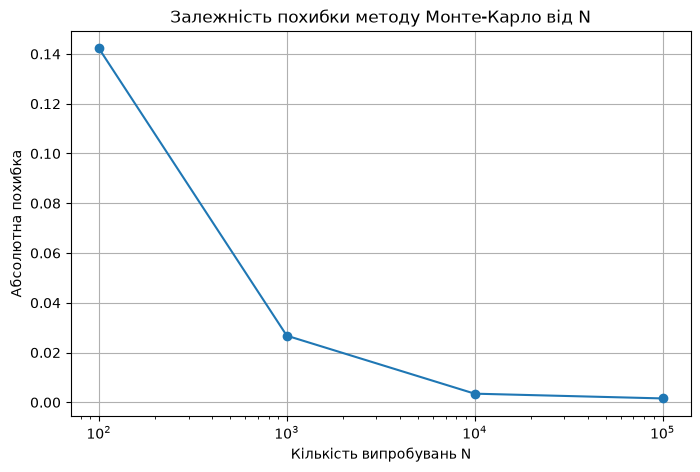

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results_df["N"],
    results_df["Абсолютна похибка"],
    marker="o"
)

ax.set_xscale("log")
ax.set_xlabel("Кількість випробувань N")
ax.set_ylabel("Абсолютна похибка")
ax.set_title("Залежність похибки методу Монте-Карло від N")
ax.grid(True)

plt.show()

### Опис графіка

Зі збільшенням кількості випробувань абсолютна похибка в цілому
має тенденцію до зменшення. Через випадковий характер симуляції
спадання не обов'язково є строго монотонним.

Форма залежності відповідає очікуваній поведінці методу Монте-Карло:
характерний масштаб похибки зменшується приблизно пропорційно
1/√N.

## Завдання 5. Зв'язок із законом великих чисел і ЦГТ

### 1. Який результат гарантує наближення до точного значення?

Оцінка методом Монте-Карло є вибірковим середнім незалежних
випадкових величин:

M_N = (1/N) Σ Y_i,

де Y_i — максимум двох кидків кубика для i-го випробування.

Закон великих чисел гарантує, що при збільшенні N вибіркове середнє
наближається до математичного сподівання E[Y].

Отже, саме закон великих чисел пояснює збіжність оцінки Монте-Карло
до точного значення.

### 2. Чому похибка зменшується як 1/√N?

Центральна гранична теорема показує, що для достатньо великого N
розподіл вибіркового середнього наближається до нормального, а його
стандартна похибка має вигляд:

σ / √N.

Тому збільшення кількості випробувань у 4 рази збільшує √N лише
у 2 рази. Відповідно, характерна статистична похибка зменшується
приблизно у 2 рази, а не у 4.

При збільшенні N у 100 разів √N збільшується у 10 разів, тому
характерний масштаб похибки зменшується приблизно у 10 разів.

## Контрольні питання

### 1. Чому оцінка Монте-Карло є вибірковим середнім?

Для кожного випробування отримуємо випадкову величину Y — максимум
двох кидків кубика. Оцінка її математичного сподівання обчислюється
як середнє значення всіх отриманих Y.

### 2. Що гарантує збіжність оцінки до точного значення?

Закон великих чисел гарантує, що вибіркове середнє наближається
до математичного сподівання при збільшенні кількості випробувань.

### 3. Чому вчетверо більша кількість випробувань дає приблизно
вдвічі меншу похибку?

Тому що стандартна похибка має вигляд σ/√N. Якщо N збільшити
у 4 рази, √N збільшиться у 2 рази.

### 4. Чому з'являється корінь із N?

Корінь виникає у формулі стандартної похибки вибіркового середнього:

σ/√N.

Це є наслідком властивостей дисперсії та центральної граничної
теореми.

### 5. Чому використовується `max(axis=1)`?

Матриця кидків має форму `(N, 2)`: кожен рядок відповідає одному
випробуванню, а два стовпці — двом кидкам кубика.

`max(axis=1)` знаходить максимум окремо в кожному рядку, тому
отримуємо N значень максимуму.

Без `axis=1` функція працювала б по всій матриці та повернула б
одне глобальне максимальне значення.